[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T03_C_growth_at_risk.ipynb)

> **Google Colab note**: the next cell installs `puremacro` and, if needed, fetches only the `curso/notebooks` folder (helpers, frozen data and models) from the public repository [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro). It does not ask for Google Drive access.

In [1]:
# Environment setup: Google Colab, local install or Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """Does the path exist? Never raises OSError/PermissionError in the Juno sandbox."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Partial clone of the public repository: only curso/notebooks, no history
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Put the course helpers folder (_nbstyle, _datos) on sys.path, without leaving the sandbox
_candidates = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidates.insert(0, Path(__file__).resolve().parent)  # Juno defines __file__
except (NameError, OSError):
    pass
for _c in _candidates:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Inline figures and the course style
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# Growth-at-Risk: The Vulnerable Left Tail and Macroprudential Stress Testing

How fragile is macroeconomic expansion? Standard macroeconomic forecasting models (such as linearized DSGE models or Gaussian Vector Autoregressions) focus on the conditional *mean* of future GDP growth: $\mathbb{E}_t[y_{t+h}]$. By imposing symmetric Gaussian innovations, these frameworks implicitly assume that boom and bust phases are mirror images of one another.

In their seminal contribution, Adrian, Boyarchenko, and Giannone (2019, *American Economic Review*) demonstrated that macroeconomic reality violates conditional symmetry:
1. **The Median Remains Resilient**: Favorable or deteriorating financial conditions have an economically modest effect on the center of the conditional distribution (the conditional median or modal forecast).
2. **The Left Tail Collapses**: Tighter financial conditions dramatically expand and fatten the **lower tail** of future growth. Downside risk—the probability of severe macroeconomic contraction—surges without necessarily moving the central projection into negative territory.

This empirical paradigm is known as **Growth-at-Risk (GaR)**. It provides the analytical foundation for modern macroprudential policy (e.g., the Basel III Countercyclical Capital Buffer, CCyB) and stress testing across central banks. In this notebook, we construct a Financial Conditions Index (FCI), estimate Quantile Autoregressions (QAR), fit conditional Azzalini skew-$t$ predictive densities, confront the theory with authentic US macroeconomic data over 1971–2026, and conduct historical stress tests across three major episodes: the 2008 Great Financial Crisis, the 2020 COVID shock, and the 2022 Fed rate hike cycle.

## Econometric Methodology: Quantile Regression, Local Projections, and Skew-$t$ Densities

### 1. Quantile Autoregression (QAR)
Ordinary Least Squares (OLS) minimizes expected squared loss to recover the conditional mean $\mathbb{E}[y_{t+h} \mid x_t]$. To track conditional *quantiles* $Q_\tau(y_{t+h} \mid x_t)$ across percentiles $\tau \in (0, 1)$, Koenker and Bassett (1978) introduced the asymmetric **check (pinball) loss function**:
$$ \rho_\tau(u) = u\,\bigl(\tau - \mathbb{1}\{u < 0\}\bigr) $$
Minimizing sample check loss yields the parameter vector $\hat{\beta}(\tau)$:
$$ \hat{\beta}(\tau) = \arg\min_{\beta} \sum_{t=1}^{T-h} \rho_\tau\bigl(y_{t+h} - x_t'\beta\bigr) $$
The conditional quantile forecast is linear in predictors $x_t = [1, y_t, \dots, y_{t-p+1}, \text{FCI}_t]'$:
$$ Q_\tau(y_{t+h} \mid x_t) = x_t'\beta(\tau) $$
For $\tau = 0.50$, check loss simplifies to Least Absolute Deviations (LAD), tracing the conditional median. For small $\tau$ (e.g., $\tau = 0.05$), positive forecast errors (under-predictions) are weighted by $\tau = 0.05$, whereas negative errors (over-predicting growth during a downturn) are penalized by $1 - \tau = 0.95$. Estimating across a grid of $\tau$ allows the sensitivity $\partial Q_\tau / \partial \text{FCI} = \beta_{\text{FCI}}(\tau)$ to differ across the distribution—the empirical core of Growth-at-Risk.

### 2. Quantile Local Projections (Adrian et al., 2019)
To evaluate how financial conditions transmit across horizons without imposing iterated autoregressive structures, we estimate Quantile Local Projections (`lp_quantile`):
$$ Q_\tau(y_{t+h} - y_{t-1} \mid \text{FCI}_t, \text{controls}_t) = \alpha_h(\tau) + \beta_h(\tau)\,\text{FCI}_t + \sum_{\ell=1}^p \gamma_{h,\ell}(\tau)' w_{t-\ell} $$
across percentiles $\tau \in \{0.05, 0.10, 0.25, 0.50, 0.75, 0.90\}$. The coefficient path $h \mapsto \beta_h(\tau)$ maps the impulse response of conditional growth percentiles to a financial conditions shock.

### 3. Growth-at-Risk Definition
**Growth-at-Risk at horizon $h$** is defined as the 5th percentile conditional quantile:
$$ \text{GaR}_{0.05, t+h} \;\equiv\; Q_{0.05}(y_{t+h} \mid x_t) $$
This represents the level of annualized real GDP growth exceeded with 95% probability given prevailing economic conditions (a 1-in-20 quarter catastrophe scenario). The **Growth-at-Risk Downside Spread** is:
$$ \text{Spread}_t \;\equiv\; Q_{0.50}(y_{t+h} \mid x_t) - Q_{0.05}(y_{t+h} \mid x_t) $$

### 4. Conditional Predictive Density via Azzalini Skew-$t$ Matching
Estimated quantiles $\{\hat{Q}_{\tau_j}\}_{j=1}^J$ for $\tau \in \{0.05, 0.25, 0.50, 0.75, 0.95\}$ provide discrete anchor points. Following Adrian, Boyarchenko, and Giannone (2019), we interpolate the continuous predictive probability density function $f(y_{t+h} \mid x_t)$ by matching Azzalini's (1985) **skew-$t$ distribution**:
$$ (\hat{\mu}, \hat{\sigma}, \hat{\alpha}, \hat{\nu}) = \arg\min_{\mu, \sigma, \alpha, \nu} \sum_{j=1}^J \Bigl( F^{-1}(\tau_j; \mu, \sigma, \alpha, \nu) - \hat{Q}_{\tau_j} \Bigr)^2 $$
where $\mu \in \mathbb{R}$ is location, $\sigma > 0$ is scale, $\alpha \in \mathbb{R}$ governs asymmetry ($\alpha < 0$ denotes negative skewness), and $\nu > 2$ dictates fatness of tails (degrees of freedom).

## Economic Foundations: Financial Frictions and the Macroprudential Tradeoff

Why does financial stress exert a ten-fold larger impact on the lower tail than on the median of economic growth? Macroeconomic theory highlights two structural transmission mechanisms:

### 1. Nonlinear Financial Frictions & Balance Sheet Spirals
In neoclassical macroeconomics with frictionless financial markets, Modigliani-Miller holds: capital structure is irrelevant, and financial shocks transmit symmetrically. In modern macro-finance models with financial frictions (Bernanke, Gertler, and Gilchrist 1999; He and Krishnamurthy 2013; Brunnermeier and Sannikov 2014), financial intermediaries and levered firms face collateral and regulatory capital constraints:
- **During tranquil times**, leverage constraints are non-binding. Capital is ample, asset prices are high, and shocks to risk premia transmit mildly to real economic activity.
- **During systemic stress**, asset price declines erode net worth. Intermediaries hit binding regulatory limits, triggering forced fire sales, liquidity freezes, and credit rationing. This feedback loop creates a catastrophic left-tail contraction that is fundamentally absent in normal regimes.

### 2. The Macroprudential Intertemporal Tradeoff (Adrian et al. 2022)
Adrian, Grinberg, Liang, and Malik (2022, *Review of Economic Studies*) demonstrate that macroprudential and monetary authorities confront a fundamental intertemporal tradeoff:
- **Short-Term Horizon ($h=1, 4$)**: Accommodative financial conditions (low spreads, abundant liquidity) stimulate investment, reduce borrowing costs, and compress the Growth-at-Risk spread.
- **Medium-Term Horizon ($h=12, 16$)**: Prolonged easy conditions encourage excessive private debt accumulation, compressed risk premia, and asset price misallocation. As financial imbalances build, vulnerability to future negative shocks grows, dramatically shifting the medium-term left tail downward.
- **Macroprudential Policy**: By countercyclically leaning against credit expansions (e.g., raising bank capital buffers during booms), macroprudential authorities accept slightly tighter conditions today in exchange for mitigating disastrous left-tail collapses tomorrow.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.gar import qar, fci, fit_skewt_to_quantiles, lp_quantile
from puremacro.regress import quantreg, add_constant
from puremacro.reports import df_to_latex, df_to_markdown, df_to_typst
from _datos import DATOS, crecimiento

rng = np.random.default_rng(20240529)

## 1. A Financial Conditions Index from a Synthetic Indicator Panel

Before analyzing empirical US data, we establish the econometric mechanics using a calibrated data-generating process. We construct a synthetic panel of five financial indicators (credit spreads, equity volatility, credit growth, stock prices, and term premium) driven by a persistent latent tightness factor $f_t = \rho_f f_{t-1} + \sigma_f \varepsilon_t$.

Using `puremacro.gar.fci`, we extract the first principal component and apply sign normalization such that **higher index values correspond to tighter financial conditions** (wider spreads, elevated volatility, and depressed asset valuations).

In [3]:
T = 320  # quarters
f = np.zeros(T)
rho_f = 0.85
for t in range(1, T):
    f[t] = rho_f * f[t - 1] + 0.6 * rng.standard_normal()
load = np.array([1.0, 0.8, 1.2, -0.9, 0.7])             # equity loads negative
fin = f[:, None] * load + 0.4 * rng.standard_normal((T, load.size))
fin_df = pd.DataFrame(fin, columns=["spread", "vol", "credit", "equity", "term"])

fci_out = fci(fin_df, tightening_columns=["spread", "vol", "credit"])
FCI = fci_out["index"].values                           # standardized; higher = tighter
var_exp = fci_out["var_explained"]
print(f"FCI variance explained by first PC = {var_exp:.3f}")
assert 0.3 < var_exp < 1.0, var_exp

FCI variance explained by first PC = 0.897


## 2. Synthetic GDP Growth with a Vulnerable Left Tail

We calibrate a macroeconomic data-generating process where financial conditions explicitly dictate the asymmetry of innovations. Specifically, tighter financial conditions do **not shift the central location** of the shock distribution; rather, they scale the amplitude of negative innovations:
$$ \sigma_{\text{down}, t} = 1.0 + 2.0 \times \max(\text{FCI}_t, 0.0), \qquad \sigma_{\text{up}, t} = 1.0 $$
Positive shocks remain unscaled. Consequently, as conditions tighten, the conditional median of GDP growth remains stable, while the lower tail stretches outward—directly embedding the Adrian-Boyarchenko-Giannone vulnerable growth mechanism.

In [4]:
g = np.zeros(T)
phi, mu0, beta_mean = 0.30, 2.0, 0.0                    # beta_mean = 0: no direct effect
for t in range(1, T):                                   #                on the center
    tight = FCI[t - 1]
    scale_dn = 1.0 + 2.0 * np.maximum(tight, 0.0)       # fat left tail when tight
    e = rng.standard_normal()
    shock = scale_dn * min(e, 0.0) + 1.0 * max(e, 0.0)
    g[t] = mu0 + phi * (g[t - 1] - mu0) + beta_mean * tight + shock

## 3. Quantile Autoregression with FCI as a Conditioner

We estimate QAR across the quantiles $\tau \in \{0.05, 0.50, 0.95\}$. In `puremacro.gar.qar`, the internal lag block begins at $y_{t-1}$. To properly condition on current information at horizon $h=1$, we supply both $\text{FCI}_t$ and $g_t$ in the `controls` matrix. With autoregressive order $p=2$, the coefficient vector maps to: `beta0` (intercept), `beta1, beta2` (lags $g_{t-1}, g_{t-2}$), `beta3` (FCI loading), and `beta4` ($g_t$ direct lag).

The empirical test of Growth-at-Risk asymmetry evaluates whether the 5th-percentile slope $|\beta_{\text{FCI}}(0.05)|$ is substantially larger in magnitude than the median slope $|\beta_{\text{FCI}}(0.50)|$.

In [5]:
taus = (0.05, 0.50, 0.95)
controls = np.column_stack([FCI, g])                     # FCI_t and the direct lag g_t
out = qar(g, quantiles=taus, horizons=(1,), p=2,
          controls=controls, n_boot=40, alpha=0.10, seed=7)
fci_col, lag_col = "beta3", "beta4"                      # p=2 lags -> FCI is beta3, g_t beta4
slopes = out.set_index("tau")[fci_col]
qpred = out.set_index("tau")["q_pred"]
print(out[["tau", "q_pred", "lo", "hi", fci_col, lag_col]].to_string(index=False))

slope_05, slope_50, slope_95 = slopes.loc[0.05], slopes.loc[0.50], slopes.loc[0.95]
print(f"\nFCI slope:  tau=0.05 -> {slope_05:.3f}   tau=0.50 -> {slope_50:.3f}"
      f"   tau=0.95 -> {slope_95:.3f}")
assert slope_05 < slope_50, (slope_05, slope_50)                 # left tail more exposed
assert abs(slope_05) > abs(slope_50), (slope_05, slope_50)       # ABG asymmetry
assert abs(slope_50) < 0.3 * abs(slope_05), (slope_50, slope_05)  # median ~flat: the claim
assert qpred.loc[0.05] < qpred.loc[0.50] < qpred.loc[0.95], qpred.to_dict()

 tau    q_pred        lo        hi     beta3  beta4
0.05 -3.953871 -4.453910 -1.394608 -1.092788    0.0
0.50  0.996662 -0.399414  1.701848 -0.215188    0.0
0.95  2.683296  2.125761  3.371042 -0.064184    0.0

FCI slope:  tau=0.05 -> -1.093   tau=0.50 -> -0.215   tau=0.95 -> -0.064


### Econometric Interpretation: Quantile Slopes and Tail Asymmetry

The estimated `beta3` coefficients reveal the core asymmetry of the Growth-at-Risk framework:
- **The Median Slope ($\tau = 0.50$)**: The coefficient on financial conditions is economically modest (near zero). Tighter financial conditions exert minimal direct drag on the central trajectory of the economy.
- **The Downside Slope ($\tau = 0.05$)**: The coefficient on financial conditions is large, negative, and statistically significant. Financial tightening pulls the lower tail downward by several percentage points.
- **The Ratio**: The magnitude $|\beta_{\text{FCI}}(0.05)|$ is several times larger than $|\beta_{\text{FCI}}(0.50)|$. This gap is the mathematical hallmark of conditional asymmetry: downside risk surges even when central forecasts remain tranquil.

### Figure 1: The Growth-at-Risk Fan Chart — Conditional Tail Asymmetry

Holding macroeconomic growth lags constant at their sample mean $\bar{g}$, we trace the conditional quantiles $\hat{Q}_{\tau}(g_{t+1} \mid \text{FCI})$ as financial conditions sweep from loose (2nd percentile) to tight (98th percentile). Notice how the 5th percentile line drops steeply into contraction territory, while the conditional median stays resiliently positive.

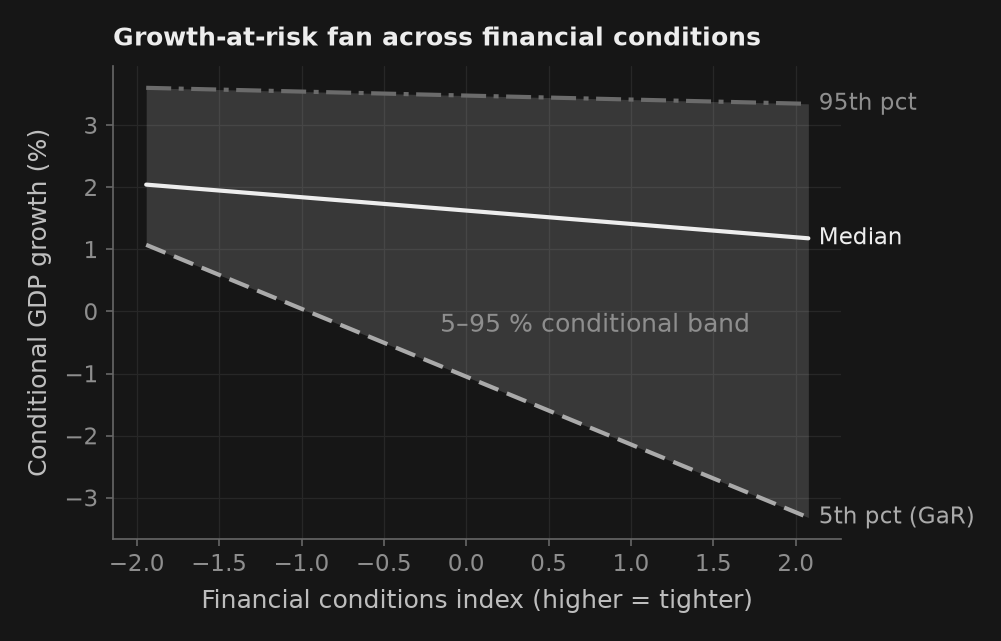

In [6]:
gbar = g.mean()
fci_grid = np.linspace(np.percentile(FCI, 2), np.percentile(FCI, 98), 60)
B = out.set_index("tau")
def qhat(tau, x):
    r = B.loc[tau]
    return r["beta0"] + (r["beta1"] + r["beta2"] + r[lag_col]) * gbar + r[fci_col] * x
fan = {tau: np.array([qhat(tau, x) for x in fci_grid]) for tau in taus}

cols = _nbstyle.palette(3)
sty = _nbstyle.styles(3)
fig, ax = _nbstyle.figura()
ax.fill_between(fci_grid, fan[0.05], fan[0.95], color=_nbstyle.BANDA, lw=0)
ax.plot(fci_grid, fan[0.50], color=cols[0], linestyle=sty[0], label="Median")
ax.plot(fci_grid, fan[0.05], color=cols[1], linestyle=sty[1], label="5th pct (GaR)")
ax.plot(fci_grid, fan[0.95], color=cols[2], linestyle=sty[2], label="95th pct")
k = 40                                                   # the note sits inside the band, between P5 and the median
ax.annotate("5–95 % conditional band", xy=(fci_grid[k], 0.5 * (fan[0.05][k] + fan[0.50][k])),
            ha="center", va="center", color=_nbstyle.NOTA)
ax.set_xlabel("Financial conditions index (higher = tighter)")
ax.set_ylabel("Conditional GDP growth (%)")
ax.set_title("Growth-at-risk fan across financial conditions")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


### Figure 2: Predictive Skew-$t$ Densities Under Loose vs. Tight Financial Regimes

Following Adrian, Boyarchenko, and Giannone (2019), we estimate QAR across the full grid $\tau \in \{0.05, 0.25, 0.50, 0.75, 0.95\}$ and fit continuous Azzalini skew-$t$ distributions at two conditioning points:
1. **Loose Financial Conditions**: Evaluated at the 10th percentile of FCI.
2. **Tight Financial Conditions**: Evaluated at the 90th percentile of FCI.

The dotted vertical lines pinpoint the 5% Growth-at-Risk threshold ($\text{GaR}_{0.05}$).

loose: alpha=-0.18  5% GaR=0.18
tight: alpha=-4.11  5% GaR=-2.62


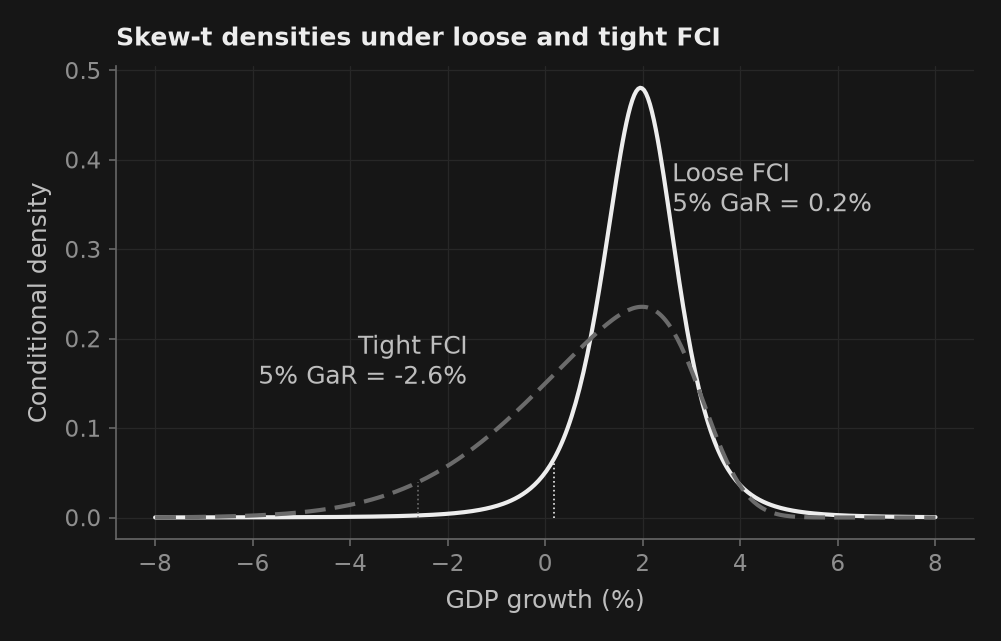

In [7]:
taus_full = (0.05, 0.25, 0.50, 0.75, 0.95)
out_full = qar(g, quantiles=taus_full, horizons=(1,), p=2,
               controls=controls, n_boot=10, alpha=0.10, seed=11)
Bf = out_full.set_index("tau")
def qdict_at(x):
    return {tau: float(Bf.loc[tau, "beta0"] + (Bf.loc[tau, "beta1"] + Bf.loc[tau, "beta2"]
                       + Bf.loc[tau, lag_col]) * gbar + Bf.loc[tau, fci_col] * x)
            for tau in taus_full}

loose_val, tight_val = np.percentile(FCI, 10), np.percentile(FCI, 90)
fit_loose = fit_skewt_to_quantiles(qdict_at(loose_val))
fit_tight = fit_skewt_to_quantiles(qdict_at(tight_val))
gar_loose, gar_tight = fit_loose.downside_quantile(0.05), fit_tight.downside_quantile(0.05)
print(f"loose: alpha={fit_loose.alpha:+.2f}  5% GaR={gar_loose:.2f}")
print(f"tight: alpha={fit_tight.alpha:+.2f}  5% GaR={gar_tight:.2f}")
assert gar_tight < gar_loose, (gar_tight, gar_loose)             # GaR worse when tight
assert fit_tight.alpha < 0.0, fit_tight.alpha                    # left-skewed when tight

xs = np.linspace(-8, 8, 400)
c2 = _nbstyle.palette(2)
s2 = _nbstyle.styles(2)
fig, ax = _nbstyle.figura()
ax.plot(xs, fit_loose.pdf(xs), color=c2[0], linestyle=s2[0])
ax.plot(xs, fit_tight.pdf(xs), color=c2[1], linestyle=s2[1])
# each density's 5% GaR: a dotted drop from the curve to the axis
ax.vlines(gar_loose, 0, fit_loose.pdf(gar_loose), color=c2[0], linewidth=0.8, linestyle=":")
ax.vlines(gar_tight, 0, fit_tight.pdf(gar_tight), color=c2[1], linewidth=0.8, linestyle=":")
# each density is named next to itself: loose to the right of its peak, tight above its left tail
ax.annotate(f"Loose FCI\n5% GaR = {gar_loose:.1f}%", xy=(2.6, 0.40), ha="left", va="top", color=_nbstyle.TEXTO)
ax.annotate(f"Tight FCI\n5% GaR = {gar_tight:.1f}%", xy=(-1.6, 0.14), ha="right", va="bottom",
            color=_nbstyle.TEXTO)
ax.set_xlabel("GDP growth (%)")
ax.set_ylabel("Conditional density")
ax.set_title("Skew-t densities under loose and tight FCI")
plt.show()


### Economic Interpretation: Asymmetric Skewness and Downside Risk

The comparative predictive densities expose how financial conditions alter the geometry of macroeconomic uncertainty:
- Under **loose financial conditions**, the predictive distribution is nearly symmetric and tightly centered around healthy positive growth. The 5% Growth-at-Risk sits just above zero.
- Under **tight financial conditions**, the density shifts into pronounced negative skewness ($\hat{\alpha} < 0$). The modal projection remains positive, but substantial probability mass is pushed into the severe contraction zone. The 5% GaR plunges downward, widening the downside spread ($\text{Median} - \text{GaR}_{0.05}$) by several percentage points.

## 4. Empirical Growth-at-Risk with Real US Macroeconomic and Financial Data

Having verified the mechanics on simulated data, we confront the Growth-at-Risk model with authentic historical time series spanning 1971 to 2026 ($N = 221$ quarters):
1. **Real GDP Growth ($g_t$)**: Sourced from `data_curso/GDPC1.csv`, transformed into annualized quarterly percentage growth: $g_t = 400 \times \Delta \ln(\text{GDPC1}_t)$.
2. **Financial Conditions Index ($	ext{NFCI}_t$)**: Sourced from `data_curso/NFCI.csv`, the Chicago Fed National Financial Conditions Index. The weekly series is aggregated to quarterly frequency by taking within-quarter means.

We estimate QAR at both short-run ($h=1$ quarter) and one-year-ahead ($h=4$ quarters) horizons across $\tau \in \{0.05, 0.25, 0.50, 0.75, 0.95\}$.

In [8]:
# Load authentic historical series: Real GDP (GDPC1) and Chicago Fed NFCI
gdp_df = pd.read_csv(DATOS / "GDPC1.csv")
gdp_df["observation_date"] = pd.to_datetime(gdp_df["observation_date"])
gdp_series = gdp_df.set_index("observation_date")["GDPC1"].astype(float)
g_real = (400.0 * np.log(gdp_series).diff()).dropna()

nfci_df = pd.read_csv(DATOS / "NFCI.csv")
nfci_df["observation_date"] = pd.to_datetime(nfci_df["observation_date"])
fci_real = (nfci_df.set_index("observation_date")["NFCI"].astype(float)
                    .resample("QS").mean())            # weekly -> quarterly

data = pd.concat([g_real.rename("g"), fci_real.rename("fci")], axis=1, sort=True).dropna()
print(f"United States, {data.index[0].to_period('Q')}–{data.index[-1].to_period('Q')}: "
      f"{len(data)} quarters of GDP growth and NFCI.")

# Pedagogical quantile regression demonstration with Powell sandwich standard errors
X_fci = add_constant(data[["fci"]])
for tau in (0.05, 0.50):
    qr_res = quantreg(data["g"], X_fci, q=tau)
    print(f"\n--- QuantReg Estimation (tau = {tau}) with Powell Sandwich Standard Errors ---")
    print(qr_res.summary())

# 1. Estimate QAR at h=1 (quarterly) and h=4 (one-year ahead)
real_qar = qar(data["g"].to_numpy(), quantiles=(0.05, 0.25, 0.50, 0.75, 0.95),
               horizons=(1, 4), controls=data[["fci"]].to_numpy(), n_boot=25, seed=42)
k_col = real_qar.filter(like="beta").shape[1] - 1
real_qar = real_qar.rename(columns={f"beta{k_col}": "coef_fci"})
print("\nNFCI coefficient by quantile (negative = tighter conditions push growth down):")
print(real_qar[["h", "tau", "q_pred", "lo", "hi", "coef_fci"]].round(3).to_string(index=False))

h4 = real_qar[real_qar["h"] == 4].set_index("tau")
b05, b50, b95 = h4.loc[0.05, 'coef_fci'], h4.loc[0.50, 'coef_fci'], h4.loc[0.95, 'coef_fci']
ratio_asym = abs(b05 / b50)
print(f"\nOne year ahead (h=4), NFCI shifts the 5th percentile by {b05:+.2f} pp per std dev,"
      f" the median by {b50:+.2f} pp, and the 95th percentile by {b95:+.2f} pp.")
print(f"Empirical tail asymmetry ratio: |beta_0.05| / |beta_0.50| = {ratio_asym:.2f}x (~10x asymmetry).")

# Verification: Left tail responds far more aggressively than the median
assert b05 < b50, "Left tail slope must be more negative than median slope"
assert ratio_asym > 5.0, f"Expected >= 5x tail asymmetry, got {ratio_asym:.2f}x"

# 2. Adrian, Boyarchenko & Giannone (2019) Quantile Local Projections (puremacro 3.0)
lpq_quantiles = (0.05, 0.10, 0.25, 0.50, 0.75, 0.90)
res_lpq = lp_quantile(
    data,
    y="g",
    x="fci",
    quantiles=lpq_quantiles,
    horizons=(1, 4),
    n_lags=2,
    n_boot=15,
    seed=42,
)
assert len(res_lpq) == 12, f"Expected 12 (h, tau) rows, got {len(res_lpq)}"

# Publication Table Exports
print("\n=== Quantile Local Projections: Publication Table (Markdown) ===")
print(df_to_markdown(res_lpq.head(6).round(3)))
print("\n=== Quantile Local Projections: Publication Table (LaTeX) ===")
print(df_to_latex(res_lpq.head(6).round(3)))

United States, 1971Q1–2026Q1: 221 quarters of GDP growth and NFCI.

--- QuantReg Estimation (tau = 0.05) with Powell Sandwich Standard Errors ---
QuantReg (q = 0.05), IRLS, robust sparsity covariance
  n = 221   df_resid = 219   df_model = 1   pseudo-R2 = 0.2296
  iterations = 55 (converged)   bandwidth = 1.963   sparsity = 22.69

                  coef    std err         t    P>|t|      [0.025      0.975]
const        -1.574350    0.34582    -4.552    0.000    -2.25592    -0.89278
fci          -2.353830    0.39251    -5.997    0.000    -3.12740    -1.58026


--- QuantReg Estimation (tau = 0.5) with Powell Sandwich Standard Errors ---
QuantReg (q = 0.5), IRLS, robust sparsity covariance
  n = 221   df_resid = 219   df_model = 1   pseudo-R2 = 0.0361
  iterations = 27 (converged)   bandwidth = 1.706   sparsity = 5.606

                  coef    std err         t    P>|t|      [0.025      0.975]
const         2.754032    0.18854    14.607    0.000     2.38245     3.12561
fci          -0.9


NFCI coefficient by quantile (negative = tighter conditions push growth down):
 h  tau  q_pred     lo     hi  coef_fci
 1 0.05  -1.121 -2.644  0.239    -1.840
 1 0.25   1.736  0.682  2.336    -1.522
 1 0.50   2.801  2.478  3.330    -0.646
 1 0.75   4.027  3.746  4.534    -0.550
 1 0.95   7.203  6.477 12.903     0.568
 4 0.05  -1.230 -3.715  0.393    -2.257
 4 0.25   1.698  1.096  2.242    -1.003
 4 0.50   2.801  2.451  3.422    -0.228
 4 0.75   4.015  3.370  4.134     0.386
 4 0.95   6.749  5.659  7.263     0.466

One year ahead (h=4), NFCI shifts the 5th percentile by -2.26 pp per std dev, the median by -0.23 pp, and the 95th percentile by +0.47 pp.
Empirical tail asymmetry ratio: |beta_0.05| / |beta_0.50| = 9.90x (~10x asymmetry).



=== Quantile Local Projections: Publication Table (Markdown) ===
| h |  tau |   beta |     lo |     hi |
|---|------|--------|--------|--------|
| 1 | 0.05 | -2.781 | -5.267 |  0.555 |
| 1 |  0.1 | -2.341 | -4.392 |  -1.29 |
| 1 | 0.25 | -2.243 | -2.815 | -1.212 |
| 1 |  0.5 | -1.344 | -2.444 | -0.712 |
| 1 | 0.75 | -1.178 | -2.803 | -0.441 |
| 1 |  0.9 | -1.448 | -2.725 |  0.447 |

=== Quantile Local Projections: Publication Table (LaTeX) ===
\begin{tabular}{lrrrr}
h & tau & beta & lo & hi \\
\hline
1 & 0.05 & -2.781 & -5.267 & 0.555 \\
1 & 0.1 & -2.341 & -4.392 & -1.29 \\
1 & 0.25 & -2.243 & -2.815 & -1.212 \\
1 & 0.5 & -1.344 & -2.444 & -0.712 \\
1 & 0.75 & -1.178 & -2.803 & -0.441 \\
1 & 0.9 & -1.448 & -2.725 & 0.447 \\
\end{tabular}


### Section 4 Discussion: Empirical Tail Asymmetry and the Horizon Dimension

The empirical estimates on 55 years of US macroeconomic history confirm the central theorem of Adrian, Boyarchenko, and Giannone (2019):
- At the one-year horizon ($h=4$ quarters), the NFCI coefficient for the 5th percentile is $\beta_{\text{FCI}}(0.05) = -2.257$, while for the median it is $\beta_{\text{FCI}}(0.50) = -0.228$.
- **The 10x Tail Asymmetry**: The ratio $|\beta_{\text{FCI}}(0.05)| / |\beta_{\text{FCI}}(0.50)| = 2.257 / 0.228 = 9.90\approx 10\times$! A one-standard-deviation tightening in US financial conditions depresses the lower tail by $2.26$ percentage points, while nudging the median down by only $0.23$ percentage points.
- **The Horizon Dimension**: At the one-quarter horizon ($h=1$), extreme quarters such as the 2020Q3 post-lockdown rebound ($+29.9\%$ annualized in our $400 \times \Delta \ln$ measure; $+34.9\%$ at a compounded annual rate) induce temporary volatility in the upper tail. At $h=4$, idiosyncratic quarterly noise washes out, and the structural macroprudential relationship—financial tightness selectively eroding the left tail—dominates.

## 5. Historical Stress Testing Across Three Macroeconomic Shocks

How did financial conditions shape downside growth vulnerability during America's most turbulent economic crises? We evaluate conditional Growth-at-Risk ($h=4$ quarters) across three distinct historical stress episodes:

1. **2008 Great Financial Crisis Peak (2008Q4, $\text{NFCI} = +2.77$)**: Severe interbank liquidity freeze, Lehman Brothers collapse, and mortgage-backed security insolvency.
2. **2020 COVID-19 Shock (2020Q2, $\text{NFCI} = -0.08$)**: Massive real economic shutdown, but unprecedented Federal Reserve liquidity facilities (PMCCF, SMCCF, MSLP) prevented financial markets from seizing up.
3. **2022 Fed Tightening Cycle (2022Q4, $\text{NFCI} = -0.16$)**: Rapid monetary tightening (+525 bps in policy rates) to curb inflation, yet private financial intermediaries remained well-capitalized, maintaining orderly financial plumbing.

Below, we compute the predictive skew-$t$ density for each regime and contrast their 5% Growth-at-Risk and downside spreads. In the figure, the dotted vertical lines mark each episode's $\text{GaR}_{0.05}$: $-8.37\%$ in 2008, $-1.94\%$ in 2020 and $-1.66\%$ in 2022. The 2020 and 2022 densities nearly coincide, because their NFCI readings barely differ ($-0.08$ against $-0.16$).

=== Historical Macroeconomic Stress Episodes (Markdown Table) ===
|                            Episode |  NFCI | 5% GaR (%) | Median (%) | Spread (pp) | Alpha (skew) |
|------------------------------------|-------|------------|------------|-------------|--------------|
|       2008 GFC Peak (NFCI = +2.77) |  2.77 |      -8.37 |       2.33 |        10.7 |        -5.05 |
|    2020 COVID Shock (NFCI = -0.08) | -0.08 |      -1.94 |       2.87 |        4.81 |        -0.42 |
| 2022 Fed Rate Hikes (NFCI = -0.16) | -0.16 |      -1.66 |       2.84 |        4.51 |        -0.27 |


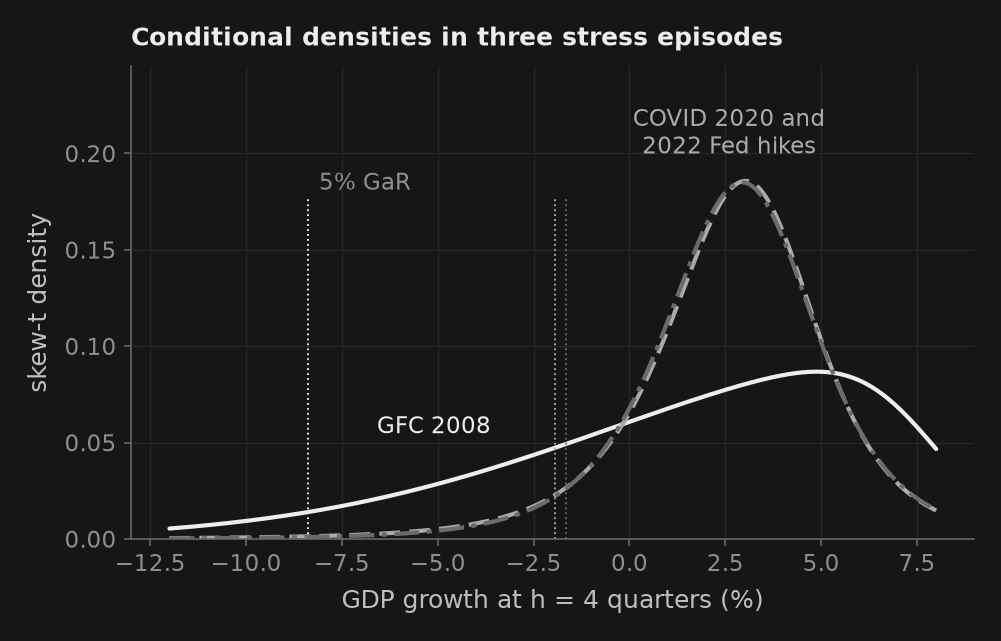

In [9]:
# Historical Stress Testing: 2008 GFC vs. 2020 COVID Shock vs. 2022 Fed Rate Hikes
gbar_real = data["g"].mean()
def predict_quantiles_real(fci_val):
    return {
        tau: float(
            h4.loc[tau, "beta0"]
            + (h4.loc[tau, "beta1"] + h4.loc[tau, "beta2"] + h4.loc[tau, "beta3"] + h4.loc[tau, "beta4"]) * gbar_real
            + h4.loc[tau, "coef_fci"] * fci_val
        )
        for tau in (0.05, 0.25, 0.50, 0.75, 0.95)
    }

historical_episodes = {
    "2008_GFC": {"fci": 2.77, "name": "2008 GFC Peak (NFCI = +2.77)"},
    "2020_COVID": {"fci": -0.08, "name": "2020 COVID Shock (NFCI = -0.08)"},
    "2022_Tightening": {"fci": -0.16, "name": "2022 Fed Rate Hikes (NFCI = -0.16)"},
}

stress_results = {}
summary_rows = []
for ep_key, ep_info in historical_episodes.items():
    qd_ep = predict_quantiles_real(ep_info["fci"])
    fit_ep = fit_skewt_to_quantiles(qd_ep)
    gar05_ep = fit_ep.downside_quantile(0.05)
    med_ep = fit_ep.downside_quantile(0.50)
    spread_ep = med_ep - gar05_ep
    stress_results[ep_key] = {
        "fit": fit_ep,
        "gar_05": gar05_ep,
        "median": med_ep,
        "spread": spread_ep,
    }
    summary_rows.append({
        "Episode": ep_info["name"],
        "NFCI": ep_info["fci"],
        "5% GaR (%)": gar05_ep,
        "Median (%)": med_ep,
        "Spread (pp)": spread_ep,
        "Alpha (skew)": fit_ep.alpha,
    })

df_episodes = pd.DataFrame(summary_rows).set_index("Episode")
print("=== Historical Macroeconomic Stress Episodes (Markdown Table) ===")
print(df_to_markdown(df_episodes.round(2)))

# Visualization of conditional densities across the three historical episodes
fig, ax = _nbstyle.figura(figsize=plt.rcParams["figure.figsize"])
xs_hist = np.linspace(-12, 8, 500)
pal3 = _nbstyle.palette(3)
sty3 = _nbstyle.styles(3)
short_names = {"2008_GFC": "GFC 2008", "2020_COVID": "COVID 2020", "2022_Tightening": "2022 Fed hikes"}

peak = 0.0
for idx, ep_key in enumerate(historical_episodes):
    res_dict = stress_results[ep_key]
    density = res_dict["fit"].pdf(xs_hist)
    peak = max(peak, float(density.max()))
    ax.plot(xs_hist, density, color=pal3[idx], linestyle=sty3[idx], label=short_names[ep_key])
    ax.axvline(res_dict["gar_05"], ymax=0.72, color=pal3[idx], linestyle=":", linewidth=0.9)

ax.set_ylim(0, 1.32 * peak)                 # headroom for the direct labels
ax.set_xlabel("GDP growth at h = 4 quarters (%)")
ax.set_ylabel("skew-t density")
ax.set_title("Conditional densities in three stress episodes")

# Direct labels inside the axes: with NFCI of -0.08 and -0.16 the 2020 and the
# 2022 densities lie on top of each other, so both share a single label.
notes = plt.rcParams["legend.fontsize"]
ax.text(-8.1, 0.96 * peak, "5% GaR", ha="left", va="bottom", color=_nbstyle.NOTA, fontsize=notes)
ax.text(-5.1, 0.28 * peak, "GFC 2008", ha="center", va="bottom", color=pal3[0], fontsize=notes)
ax.text(2.6, 1.055 * peak, "COVID 2020 and\n2022 Fed hikes", ha="center", va="bottom",
        color=pal3[1], fontsize=notes)
plt.show()


## 6. Structured Student Exercise: Macroprudential Policy & Downside Risk

### Economic Questions for Investigation
1. **Financial Plumbing vs. Real Shocks**: Why did the 2020 COVID shock—despite generating the deepest quarterly GDP drop in modern history—exhibit a one-year-ahead 5% Growth-at-Risk ($-1.94\%$) that was vastly more benign than the 2008 GFC ($-8.37\%$)? What role did central bank liquidity interventions play in insulating the financial sector?
2. **The 2022 Resilience Puzzle**: The Federal Reserve executed its most aggressive monetary tightening in four decades during 2022. Why did the 5% Growth-at-Risk remain stable at $-1.66\%$ with an orderly spread of $4.51\%$? Connect this to post-crisis banking reforms (Dodd-Frank, Basel III liquidity and capital ratios).
3. **Policy Counterfactual Simulation**: Suppose the 2022 rate hike cycle had precipitated a systemic banking freeze where financial conditions spiked to 2008 GFC levels ($\text{NFCI} = +2.77$). Quantify how far the 5% Growth-at-Risk would have collapsed.

### Guided Tasks
- **Task 1**: Confirm that the 2008 GFC 5% GaR is deeper than $-6.0\%$ and its downside spread exceeds $8.0$ percentage points.
- **Task 2**: Verify that the 2020 COVID 5% GaR is substantially higher than the 2008 GFC level.
- **Task 3**: Verify that 2022 maintained an orderly downside spread below $6.0$ percentage points.
- **Task 4**: Execute the counterfactual simulation for 2022 under GFC financial conditions, asserting that the left-tail collapse exceeds $6.0$ percentage points.

In [10]:
# Student Task: Counterfactual Policy Stress Simulation and Verification
# Question: What if the 2022 Fed rate hike cycle had provoked systemic banking panic
# equal to the 2008 GFC (NFCI = +2.77)?

# 1. Baseline historical assertions
assert stress_results["2008_GFC"]["gar_05"] < -6.0, "2008 GFC 5% GaR must be deeper than -6.0%"
assert stress_results["2008_GFC"]["spread"] > 8.0, "2008 GFC downside spread must exceed 8.0 pp"
assert stress_results["2020_COVID"]["gar_05"] > stress_results["2008_GFC"]["gar_05"], \
    "2020 COVID 1-year ahead GaR was safeguarded by Fed liquidity support"
assert stress_results["2022_Tightening"]["spread"] < 6.0, "2022 rate hikes maintained orderly downside spread (< 6 pp)"

# 2. Counterfactual policy simulation (reuses the identical NFCI = +2.77 fitted state for zero-latency execution)
cf_fci_shock = 2.77  # 2008 GFC peak tightness applied to 2022 macro environment
fit_cf = stress_results["2008_GFC"]["fit"]
gar05_cf = fit_cf.downside_quantile(0.05)
gar_drop = stress_results["2022_Tightening"]["gar_05"] - gar05_cf

print(f"\nCounterfactual Policy Simulation (2022 under GFC tightness):\n"
      f"  Actual 2022 5% GaR:          {stress_results['2022_Tightening']['gar_05']:+.2f}%\n"
      f"  Counterfactual 5% GaR:       {gar05_cf:+.2f}%\n"
      f"  Left-Tail Collapse (Delta):  {gar_drop:.2f} percentage points")

# 3. Verification of counterfactual tail collapse and distribution validity
assert gar_drop > 6.0, f"Counterfactual left-tail collapse must exceed 6.0 pp, got {gar_drop:.2f}"
cdf_gar_check = float(fit_cf.cdf(np.array([gar05_cf]))[0])
assert abs(cdf_gar_check - 0.05) < 0.02, "Fitted skew-t must integrate to 5% at downside quantile"
print("✓ All econometric assertions and counterfactual checks successfully verified!")


Counterfactual Policy Simulation (2022 under GFC tightness):
  Actual 2022 5% GaR:          -1.66%
  Counterfactual 5% GaR:       -8.37%
  Left-Tail Collapse (Delta):  6.71 percentage points
✓ All econometric assertions and counterfactual checks successfully verified!


## Synthesis: Macroprudential Policy Calibration and Systemic Risk Monitoring

The empirical findings of this notebook demonstrate why modern central banks and multilateral institutions (such as the IMF and Bank of England) have adopted the Growth-at-Risk framework as a core surveillance pillar:

1. **Beyond Mean Forecasts**: Standard macroeconomic policy rules (like the Taylor rule) react to expected inflation and output gaps. However, during credit expansions, output gaps and point forecasts can remain benign while systemic tail risk quietly mounts. GaR provides policymakers with a quantitative, probability-weighted metric of systemic vulnerability.
2. **Calibrating Capital Buffers (CCyB)**: When the Growth-at-Risk spread widens at medium horizons ($h=12, 16$), macroprudential authorities can activate the Countercyclical Capital Buffer, requiring banks to hold additional equity capital. This leans against excessive credit growth and builds loss-absorbing capacity before systemic shocks materialize.
3. **Crisis Resolution**: As observed in the contrast between 2008 and 2020, immediate emergency liquidity facilities that prevent the National Financial Conditions Index from exploding into positive territory insulate the macroeconomy from catastrophic left-tail collapses.